In [166]:
import QUANTAXIS as QA
from QUANTAXIS.QAData import QA_DataStruct_Stock_block
from QUANTAXIS.QAUtil import  trade_date_sse
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

import DescTools as dt
import seaborn as sns

__LOW_FREQUENCE__ = [QA.FREQUENCE.YEAR, QA.FREQUENCE.QUARTER, QA.FREQUENCE.MONTH, QA.FREQUENCE.WEEK, QA.FREQUENCE.DAY]   

    

class Hy:
    def __init__(self,hytype='tdxhy', end='2021-03-19', gap=60, start=None, frequence=QA.FREQUENCE.DAY, MA=20):
        self._hy_type=hytype
        self.end = end
        self.gap = gap
        self.MA = MA
        if start is None:
            self.start = trade_date_sse[trade_date_sse.index(end)-self.gap]
        else:
            self.start = start
        self.blocks_view = self.get_blocks_view()
        self.pivot = None
        self.frequence = frequence
        
    @property
    def hy_type(self):
        return self._hy_type
    
    @hy_type.setter
    def hy_type(self, value):
        if not value in ['tdxhy','swhy','gn']:
            raise TypeError('hy_type MUST BE [tdxhy|swhy|gn]')
        self._hy_type=value
        self.blocks_view = self.get_blocks_view()
        
    @property
    def is_low_frequence(self):
        return self.frequence in __LOW_FREQUENCE__

    
    def fit(self, blocks=None):
        if blocks is None or blocks == 'all':
            ma_above = self.blocks_view.apply(self.check_MA_above)
        elif isinstance(blocks, list):
            ma_above = self.blocks_view[blocks].apply(self.check_MA_above)
        else:
            raise TypeError('fit(blocks) params error')
        tmp = ma_above.reset_index()
        if self.is_low_frequence:
            date_label = 'date'
        else:
            date_label = 'datetime'
        rebuid_df = pd.DataFrame({'blockname':tmp.blockname.repeat(tmp[0].str.len()),date_label:[i[0] for i in np.concatenate(tmp[0].values)],'-':[i[1] for i in np.concatenate(tmp[0].values)]})
        self.pivot = rebuid_df.pivot(index=date_label, columns='blockname')
        print('hangye pivot fit finish')

        
    def get_blocks_view(self):
        a = QA.QA_fetch_stock_block_adv().data
        blocks_view = a[a['type'] == self._hy_type].groupby(level=0).apply(
            lambda x:[item for item in x.index.remove_unused_levels().levels[1]]
        )
        return blocks_view
    
    def check_MA_above(self, hy_codes):
        try:
            data = QA.QA_quotation(hy_codes, self.start, self.end, source=QA.DATASOURCE.MONGO,
                               frequence=self.frequence, market=QA.MARKET_TYPE.STOCK_CN,
                               output=QA.OUTPUT_FORMAT.DATASTRUCT)
        except Exception as e:
            print(e)
            return []

        close = data.close
        count = len(hy_codes)
        compared = close[19*count:] > close.groupby(level=1).apply(lambda x: QA.MA(x, self.MA))[19*count:]
        if self.is_low_frequence:
            date_label = 'date'
        else:
            date_label = 'datetime'
        res = compared.groupby(level=0).apply(lambda x: (x.index.get_level_values(date_label)[0], round(np.sum(x)/len(x),2)))
        return res.values
    
    def JCSC(self, ma=5):
        return self.pivot.apply(lambda x: QA.CROSS(x,QA.MA(x,ma))+QA.CROSS(QA.MA(x,ma),x)*-1, axis=0)
    
    def trend(self, window=3, absolute=False):
        if absolute:
            return self.pivot.apply(lambda x: round((x-QA.MA(x,window))/QA.MA(x,window),2), axis=0)
        self.pivot.apply(lambda x: round((x-x.shift(window))/x.shift(window),2), axis=0)
    
    def plot(self):
        formater = '%Y%m%d' if self.is_low_frequence else '%Y%m%d %H%M%S'
        y_label = [pd.to_datetime(x).strftime(formater) for x in self.pivot.index.values]
        stock_in_block_s = self.blocks_view.apply(lambda x:len(x))
        xlabel = [columns[1]+'('+str(stock_in_block_s[columns[1]])+')' for columns in hy.pivot.columns]

        block_count = len(self.pivot.columns)
        
        if block_count > 100:
            self._plot(self.pivot.iloc[:,0:int(block_count/2)], y_label, xlabel[0:int(block_count/2)])
            self._plot(self.pivot.iloc[:,int(block_count/2):block_count], y_label, xlabel[int(block_count/2):block_count])
        else:
            self._plot(self.pivot, y_label, xlabel)
    
    def _plot(self,data,y_label,xlabel):
        width = 40*len(data.columns)
        high = 15*len(data.index)
        if width > 2100:width = 2100
        if high < 520:high = 520
        fig = plt.figure(figsize=(width/72,high/72))
        ax = sns.heatmap(data,fmt='.2f', yticklabels=y_label, xticklabels=xlabel, 
                         linewidths=0.5,cbar=False,cmap='YlGnBu')
        plt.xticks(rotation = -90)
        plt.show()


In [113]:
%%time
hy = Hy(hytype='tdxhy', end='2021-03-19', gap=1, frequence=QA.FREQUENCE.FIVE_MIN)
hy.fit()

hangye pivot fit finish
Wall time: 25.1 s


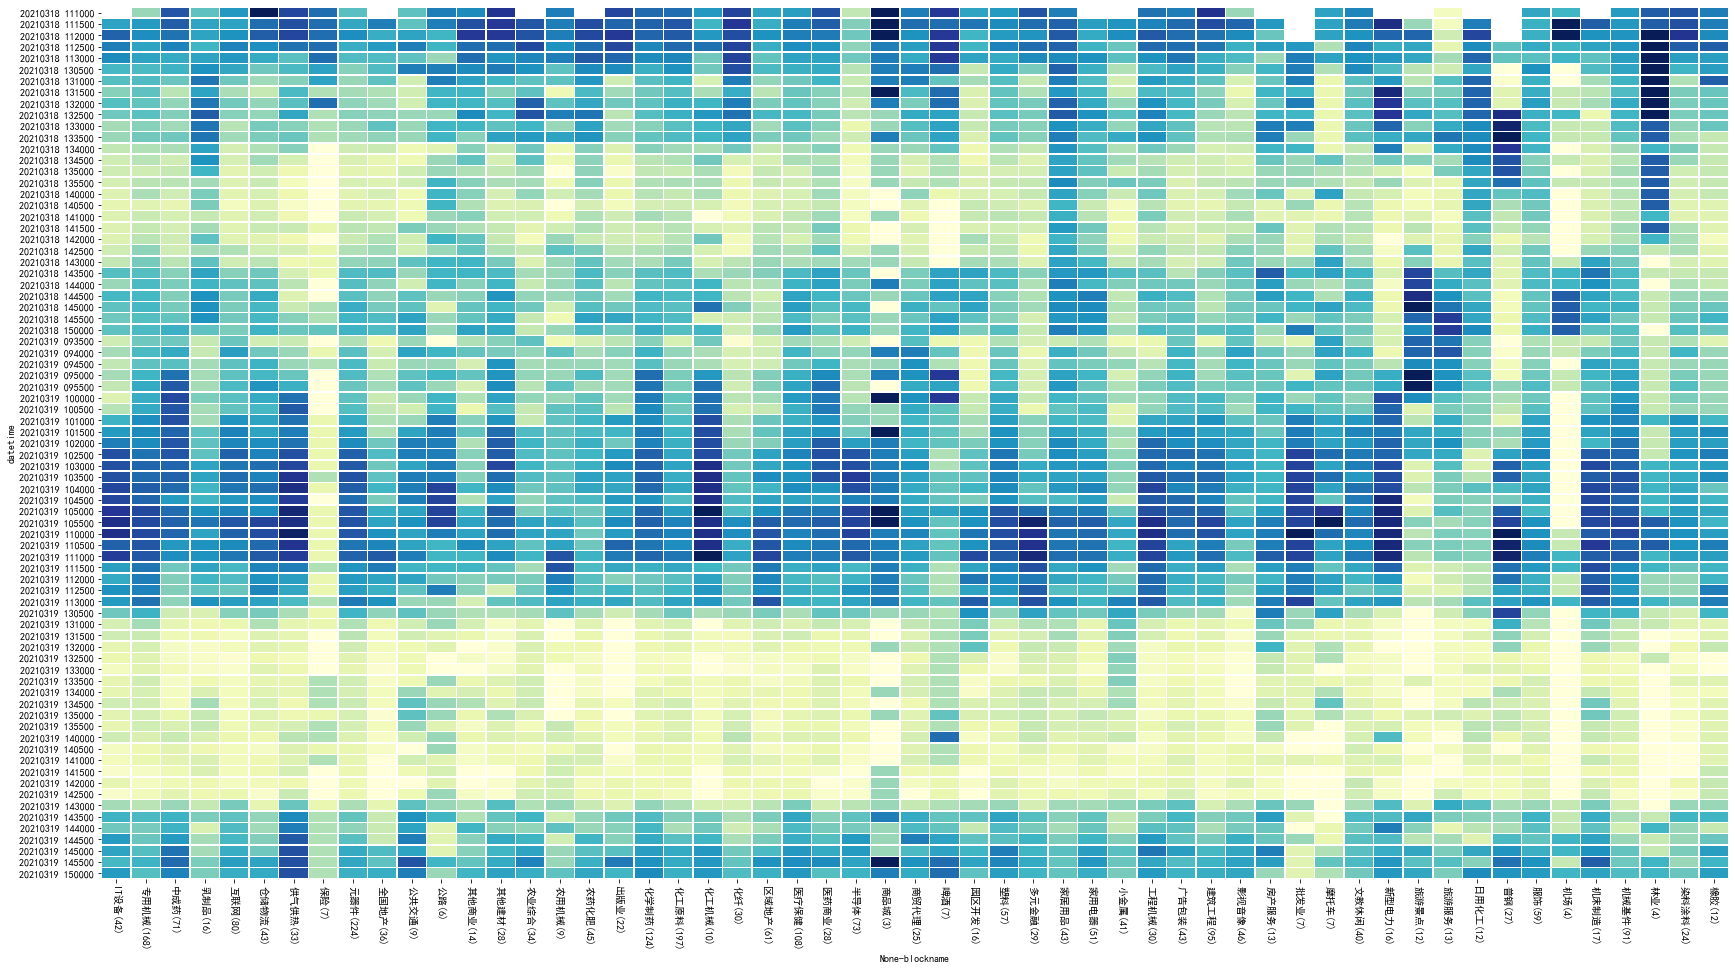

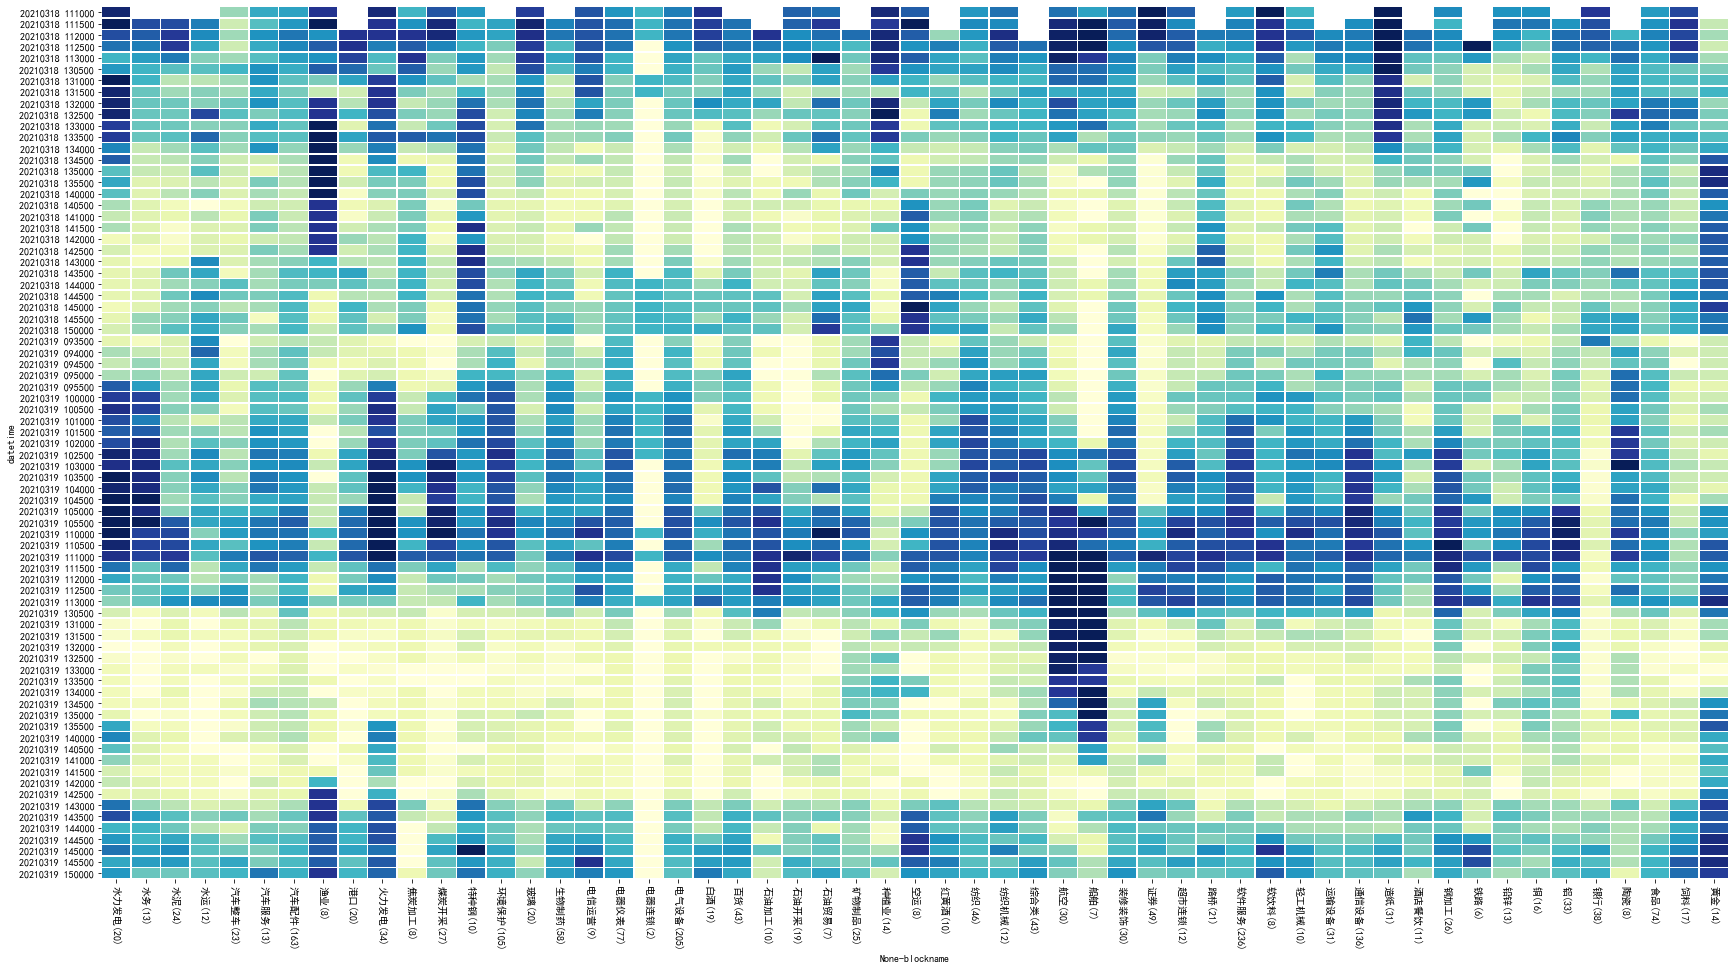

Wall time: 5.39 s


In [114]:
%%time
hy.plot()

In [116]:
hy.pivot


-                                                  \
blockname            IT设备  专用机械   中成药   乳制品   互联网  仓储物流  供气供热    保险   元器件   
datetime                                                                    
2021-03-18 11:10:00   NaN  0.33  0.77  0.44  0.60  1.00  0.82  0.71  0.45   
2021-03-18 11:15:00  0.57  0.59  0.75  0.56  0.57  0.71  0.79  0.71  0.55   
2021-03-18 11:20:00  0.74  0.63  0.70  0.56  0.62  0.75  0.82  0.71  0.63   
2021-03-18 11:25:00  0.67  0.56  0.66  0.50  0.66  0.63  0.70  0.71  0.53   
2021-03-18 11:30:00  0.64  0.56  0.54  0.56  0.60  0.54  0.45  0.71  0.47   
...                   ...   ...   ...   ...   ...   ...   ...   ...   ...   
2021-03-19 14:40:00  0.41  0.39  0.51  0.19  0.47  0.32  0.67  0.29  0.35   
2021-03-19 14:45:00  0.59  0.42  0.59  0.31  0.49  0.37  0.76  0.29  0.45   
2021-03-19 14:50:00  0.56  0.46  0.70  0.31  0.53  0.41  0.79  0.29  0.54   
2021-03-19 14:55:00  0.49  0.51  0.72  0.38  0.58  0.56  0.79  0.29  0.55   
2021-03-19 15:00:00  0.59  0.46  0.66  0.38  0.53  0.54  0.79  0.29  0.52   

                           ...                                                 \
blockname            全国地产  ...   钢加工   铁路    铅锌     铜     铝    银行    陶瓷    食品   
datetime                   ...                                                  
2021-03-18 11:10:00   NaN  ...  0.64  NaN  0.62  0.62   NaN  0.87   NaN  0.59   
2021-03-18 11:15:00  0.67  ...  0.50  NaN  0.69  0.69  0.61  0.79   NaN  0.62   
2021-03-18 11:20:00  0.53  ...  0.64  NaN  0.62  0.50  0.71  0.76  0.50  0.66   
2021-03-18 11:25:00  0.59  ...  0.60  1.0  0.54  0.38  0.71  0.74  0.71  0.61   
2021-03-18 11:30:00  0.47  ...  0.42  0.6  0.31  0.25  0.58  0.50  0.71  0.54   
...                   ...  ...   ...  ...   ...   ...   ...   ...   ...   ...   
2021-03-19 14:40:00  0.24  ...  0.42  0.2  0.38  0.31  0.29  0.37  0.29  0.31   
2021-03-19 14:45:00  0.24  ...  0.62  0.6  0.38  0.44  0.39  0.34  0.29  0.40   
2021-03-19 14:50:00  0.47  ...  0.65  0.8  0.46  0.38  0.48  0.58  0.29  0.50   
2021-03-19 14:55:00  0.44  ...  0.58  0.8  0.38  0.31  0.52  0.47  0.29  0.50   
2021-03-19 15:00:00  0.53  ...  0.54  0.4  0.31  0.38  0.45  0.53  0.14  0.50   

                                 
blockname              饲料    黄金  
datetime                         
2021-03-18 11:10:00  0.82   NaN  
2021-03-18 11:15:00  0.88  0.25  
2021-03-18 11:20:00  0.82  0.31  
2021-03-18 11:25:00  0.88  0.23  
2021-03-18 11:30:00  0.76  0.31  
...                   ...   ...  
2021-03-19 14:40:00  0.53  0.77  
2021-03-19 14:45:00  0.59  0.92  
2021-03-19 14:50:00  0.65  0.92  
2021-03-19 14:55:00  0.76  0.92  
2021-03-19 15:00:00  0.71  0.85  

[77 rows x 110 columns]

In [165]:
print(hy.pivot.iloc[:, 0:8].apply(lambda x: round((x-x.shift(3))/x.shift(3),2), axis=0))
hy.pivot.iloc[:, 0:8].apply(lambda x: round((x-QA.MA(x,3))/QA.MA(x,3),2), axis=0)
# hy.pivot.iloc[:, 0:4].apply(lambda x: x.shift(1), axis=0)
# CROSS_JC=QA.CROSS(DIFF,DEA)
# CROSS_SC=QA.CROSS(DEA,DIFF)


                        -                                          
blockname            IT设备  专用机械   中成药   乳制品   互联网  仓储物流  供气供热    保险
datetime                                                           
2021-03-18 11:10:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2021-03-18 11:15:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2021-03-18 11:20:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2021-03-18 11:25:00   NaN  0.70 -0.14  0.14  0.10 -0.37 -0.15  0.00
2021-03-18 11:30:00  0.12 -0.05 -0.28  0.00  0.05 -0.24 -0.43  0.00
...                   ...   ...   ...   ...   ...   ...   ...   ...
2021-03-19 14:40:00  7.20  2.90  2.19  0.58  2.36  5.40  1.79   inf
2021-03-19 14:45:00  0.90  0.56  0.79  0.24  0.26  1.47  0.81  1.07
2021-03-19 14:50:00  0.10 -0.04  0.37 -0.18  0.20  0.21  0.23  0.00
2021-03-19 14:55:00  0.20  0.31  0.41  1.00  0.23  0.75  0.18  0.00
2021-03-19 15:00:00  0.00  0.10  0.12  0.23  0.08  0.46  0.04  0.00

[77 rows x 8 columns]


-                                          
blockname            IT设备  专用机械   中成药   乳制品   互联网  仓储物流  供气供热    保险
datetime                                                           
2021-03-18 11:10:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2021-03-18 11:15:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2021-03-18 11:20:00   NaN  0.22 -0.05  0.08  0.04 -0.09  0.01  0.00
2021-03-18 11:25:00  0.02 -0.06 -0.06 -0.07  0.07 -0.10 -0.09  0.00
2021-03-18 11:30:00 -0.06 -0.04 -0.15  0.04 -0.04 -0.16 -0.31  0.00
...                   ...   ...   ...   ...   ...   ...   ...   ...
2021-03-19 14:40:00 -0.00  0.03  0.13 -0.30  0.08  0.19  0.16  0.21
2021-03-19 14:45:00  0.17 -0.02  0.10  0.06  0.05  0.08  0.10 -0.00
2021-03-19 14:50:00  0.08  0.09  0.17  0.15  0.07  0.12  0.07 -0.00
2021-03-19 14:55:00 -0.10  0.10  0.07  0.14  0.09  0.25  0.01 -0.00
2021-03-19 15:00:00  0.08 -0.03 -0.05  0.07 -0.03  0.07 -0.00 -0.00

[77 rows x 8 columns]